In [1]:
# Re-import necessary libraries after environment reset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Sample rowing data from previous context
row_data = {
    "skulls": [
        {"gender": "men", "numberOfRowers": 1, "time": "6:30.74"},
        {"gender": "men", "numberOfRowers": 2, "time": "5:59.72"},
        {"gender": "men", "numberOfRowers": 4, "time": "5:32.03"},
        {"gender": "women", "numberOfRowers": 1, "time": "7:07.71"},
        {"gender": "women", "numberOfRowers": 2, "time": "6:37.31"},
        {"gender": "women", "numberOfRowers": 4, "time": "6:05.13"}
    ],
    "coxless rowing": [
        {"gender": "men", "numberOfRowers": 2, "time": "6:08.50"},
        {"gender": "men", "numberOfRowers": 4, "time": "5:37.86"},
        {"gender": "women", "numberOfRowers": 2, "time": "6:47.11"},
        {"gender": "women", "numberOfRowers": 4, "time": "6:14.36"}
    ],
    "coxed rowing": [
        {"gender": "men", "numberOfRowers": 2, "time": "6:33.26"},
        {"gender": "men", "numberOfRowers": 4, "time": "5:58.96"},
        {"gender": "men", "numberOfRowers": 8, "time": "5:18.68"}
    ]
}

# Function to convert time format (mm:ss.xx) to total seconds
def time_to_seconds(time_str):
    minutes, seconds = map(float, time_str.split(':'))
    return minutes * 60 + seconds

# Prepare lists for crew size and times for men and women
men_crew_sizes = []
men_times = []
women_crew_sizes = []
women_times = []

# Iterate through the data and categorize it
for entry in row_data['coxless rowing']:
    crew_size = entry['numberOfRowers']
    time_in_seconds = time_to_seconds(entry['time'])
    
    if entry['gender'] == 'men':
        men_crew_sizes.append(crew_size)
        men_times.append(time_in_seconds)
    elif entry['gender'] == 'women':
        women_crew_sizes.append(crew_size)
        women_times.append(time_in_seconds)

# Convert lists to numpy arrays
men_crew_sizes = np.array(men_crew_sizes).reshape(-1, 1)
men_times = np.array(men_times)
women_crew_sizes = np.array(women_crew_sizes).reshape(-1, 1)
women_times = np.array(women_times)

# Convert times (seconds) to speed (km/h)
def time_to_speed_kmh(time_seconds):
    return (2000 / time_seconds) * 3.6  # 2000 meters race, conversion factor to km/h

# Convert times to speeds for men and women
men_speeds = np.array([time_to_speed_kmh(t) for t in men_times])
women_speeds = np.array([time_to_speed_kmh(t) for t in women_times])

# Convert crew size and speeds to log10 space
men_crew_sizes_log = np.log10(men_crew_sizes)
women_crew_sizes_log = np.log10(women_crew_sizes)
men_speeds_log = np.log10(men_speeds)
women_speeds_log = np.log10(women_speeds)

# Initialize and train linear regression models for men and women with log10 speeds
men_regression_speed_log = LinearRegression().fit(men_crew_sizes_log, men_speeds_log)
women_regression_speed_log = LinearRegression().fit(women_crew_sizes_log, women_speeds_log)
print("Men's Regression Results:")
print(f"Slope: {men_regression_speed_log.coef_[0]}, Intercept: {men_regression.intercept_}")

# Predict speeds for men and women in log10 space
men_predicted_speeds_log = men_regression_speed_log.predict(men_crew_sizes_log)
women_predicted_speeds_log = women_regression_speed_log.predict(women_crew_sizes_log)

# Calculate residuals for men and women in log10 space (speeds)
men_residuals_speed_log = men_speeds_log - men_predicted_speeds_log
women_residuals_speed_log = women_speeds_log - women_predicted_speeds_log

# Plotting the results for men's speeds in log10 space
plt.figure(figsize=(10, 5))

# Plot actual and predicted speeds for men
plt.subplot(1, 2, 1)
plt.scatter(men_crew_sizes_log, men_speeds_log, label='Actual (log10)', color='blue')
plt.plot(men_crew_sizes_log, men_predicted_speeds_log, label='Predicted (log10)', color='orange')
plt.title("Men's 2000m Speeds (log10 space)")
plt.xlabel('log10(Crew Size)')
plt.ylabel('log10(Speed)')
plt.legend()

# Plot residuals for men (speeds)
plt.subplot(1, 2, 2)
plt.bar([str(x[0]) for x in men_crew_sizes_log], men_residuals_speed_log, color='green')
plt.title("Men's Residuals (log10 space, Speed)")
plt.xlabel('log10(Crew Size)')
plt.ylabel('Residual (log10 Speed)')

plt.tight_layout()
plt.show()

# Plotting the results for women's speeds in log10 space
plt.figure(figsize=(10, 5))

# Plot actual and predicted speeds for women
plt.subplot(1, 2, 1)
plt.scatter(women_crew_sizes_log, women_speeds_log, label='Actual (log10)', color='blue')
plt.plot(women_crew_sizes_log, women_predicted_speeds_log, label='Predicted (log10)', color='orange')
plt.title("Women's 2000m Speeds (log10 space)")
plt.xlabel('log10(Crew Size)')
plt.ylabel('log10(Speed)')
plt.legend()

# Plot residuals for women (speeds)
plt.subplot(1, 2, 2)
plt.bar([str(x[0]) for x in women_crew_sizes_log], women_residuals_speed_log, color='green')
plt.title("Women's Residuals (log10 space, Speed)")
plt.xlabel('log10(Crew Size)')
plt.ylabel('Residual (log10 Speed)')

plt.tight_layout()
plt.show()


Men's Regression Results:


NameError: name 'men_regression' is not defined

In [ ]:
import re
from sklearn.linear_model import LinearRegression
import numpy as np

# Function to convert time format (mm:ss.xx) to total seconds
def time_to_seconds(time_str):
    minutes, seconds = map(float, time_str.split(':'))
    return minutes * 60 + seconds

# Extract data for men and women separately from the given row_data
row_data = {
    "coxless skulling": [
      {
          "gender": "men",
      	  "numberOfRowers": 1,
          "time": "6:30.74",
      },
      {
          "gender": "men",
      	  "numberOfRowers": 2,
          "time": "5:59.72",
      },
      {
          "gender": "men",
      	  "numberOfRowers": 4,
          "time": "5:32.03",
      },
      {
          "gender": "women",
      	  "numberOfRowers": 1,
          "time": "7:07.71",
      },
      {
          "gender": "women",
      	  "numberOfRowers": 2,
          "time": "6:37.31",
      },
      {
          "gender": "women",
      	  "numberOfRowers": 4,
          "time": "6:05.13",
      },
    ],
    "coxless rowing": [
      {
          "gender": "men",
          "numberOfRowers": 2,
          "time": "6:07.50",
      },
      {
          "gender": "men",
          "numberOfRowers": 4,
          "time": "5:37.86",
      },
      {
          "gender": "women",
          "numberOfRowers": 2,
          "time": "6:22.91",
      },
      {
          "gender": "women",
          "numberOfRowers": 4,
          "time": "5:43.16",
      },
    ],
    "coxed rowing": [
      {
          "gender": "men",
          "numberOfRowers": 2,
          "time": "6:33.26",
      },
      {
          "gender": "men",
          "numberOfRowers": 4,
          "time": "5:58.96",
      },
      {
          "gender": "men",
          "numberOfRowers": 8,
          "time": "5:18.68",
      }
    ]
}

# Prepare lists for crew size and times for men and women
men_crew_sizes = []
men_times = []
women_crew_sizes = []
women_times = []

# Iterate through the data and categorize it
for entry in row_data['coxless skulling', 'coxless rowing', 'coxed rowing']:
    crew_size = entry['numberOfRowers']
    time_in_seconds = time_to_seconds(entry['time'])
    
    if entry['gender'] == 'men':
        men_crew_sizes.append(crew_size)
        men_times.append(time_in_seconds)
    elif entry['gender'] == 'women':
        women_crew_sizes.append(crew_size)
        women_times.append(time_in_seconds)

# Convert lists to numpy arrays
men_crew_sizes = np.array(men_crew_sizes).reshape(-1, 1)
men_times = np.array(men_times)
women_crew_sizes = np.array(women_crew_sizes).reshape(-1, 1)
women_times = np.array(women_times)

# Initialize and train linear regression models for men and women
men_regression = LinearRegression().fit(men_crew_sizes, men_times)
women_regression = LinearRegression().fit(women_crew_sizes, women_times)

# Predict times for men and women
men_predicted_times = men_regression.predict(men_crew_sizes)
women_predicted_times = women_regression.predict(women_crew_sizes)

# Calculate residuals for men and women
men_residuals = men_times - men_predicted_times
women_residuals = women_times - women_predicted_times

# Output results for men
print("Men's Regression Results:")
print(f"Slope: {men_regression.coef_[0]}, Intercept: {men_regression.intercept_}")
print(f"Predicted Times: {men_predicted_times}")
print(f"Residuals: {men_residuals}")

# Output results for women
print("\nWomen's Regression Results:")
print(f"Slope: {women_regression.coef_[0]}, Intercept: {women_regression.intercept_}")
print(f"Predicted Times: {women_predicted_times}")
print(f"Residuals: {women_residuals}")


KeyError: ('coxless skulling', 'coxless rowing', 'coxed rowing')

In [ ]:
import re
from sklearn.linear_model import LinearRegression
import numpy as np

# Function to convert time format (mm:ss.xx) to total seconds
def time_to_seconds(time_str):
    minutes, seconds = map(float, time_str.split(':'))
    print(minutes * 60 + seconds)
    return minutes * 60 + seconds

# Extract data for men and women separately from the given row_data
row_data = {
    "coxless skulling": [
        {"gender": "men", "numberOfRowers": 1, "time": "6:30.74"},
        {"gender": "men", "numberOfRowers": 2, "time": "5:59.72"},
        {"gender": "men", "numberOfRowers": 4, "time": "5:32.03"},
        {"gender": "women", "numberOfRowers": 1, "time": "7:07.71"},
        {"gender": "women", "numberOfRowers": 2, "time": "6:37.31"},
        {"gender": "women", "numberOfRowers": 4, "time": "6:05.13"}
    ],
    "coxless rowing": [
        {"gender": "men", "numberOfRowers": 2, "time": "6:08.50"},
        {"gender": "men", "numberOfRowers": 4, "time": "5:37.86"},
        {"gender": "women", "numberOfRowers": 2, "time": "6:47.11"},
        {"gender": "women", "numberOfRowers": 4, "time": "6:14.36"}
    ],
    "coxed rowing": [
        {"gender": "men", "numberOfRowers": 2, "time": "6:33.26"},
        {"gender": "men", "numberOfRowers": 4, "time": "5:58.96"},
        {"gender": "men", "numberOfRowers": 8, "time": "5:18.68"}
    ]
}

# Prepare lists for crew size and times for men and women
men_crew_sizes = []
men_times = []
women_crew_sizes = []
women_times = []

# Iterate through each category and each race entry within it
for category, races in row_data.items():
    for entry in races:
        crew_size = entry['numberOfRowers']
        time_in_seconds = time_to_seconds(entry['time'])

        if entry['gender'] == 'men':
            men_crew_sizes.append(crew_size)
            men_times.append(time_in_seconds)
        elif entry['gender'] == 'women':
            women_crew_sizes.append(crew_size)
            women_times.append(time_in_seconds)

# Convert lists to numpy arrays
men_crew_sizes = np.array(men_crew_sizes).reshape(-1, 1)
men_times = np.array(men_times)
women_crew_sizes = np.array(women_crew_sizes).reshape(-1, 1)
women_times = np.array(women_times)

men_crew_sizes = np.log10(men_crew_sizes)
men_times = np.log10(men_times)

women_crew_sizes = np.log10(women_crew_sizes)
women_times = np.log10(women_times)
# Initialize and train linear regression models for men and women
men_regression = LinearRegression().fit(men_crew_sizes, men_times)
women_regression = LinearRegression().fit(women_crew_sizes, women_times)

# Predict times for men and women
men_predicted_times = men_regression.predict(men_crew_sizes)
women_predicted_times = women_regression.predict(women_crew_sizes)

# Calculate residuals for men and women
men_residuals = men_times - men_predicted_times
women_residuals = women_times - women_predicted_times

# Output results for men
print("Men's Regression Results:")
print(f"Slope: {men_regression.coef_[0]}, Intercept: {men_regression.intercept_}")


# Output results for women
print("\nWomen's Regression Results:")
print(f"Slope: {women_regression.coef_[0]}, Intercept: {women_regression.intercept_}")



390.74
359.72
332.03
427.71
397.31
365.13
368.5
337.86
407.11
374.36
393.26
358.96
318.68
Men's Regression Results:
Slope: -0.1045634678213001, Intercept: 2.599375696914129

Women's Regression Results:
Slope: -0.10743824198492855, Intercept: 2.6339560855004707


In [ ]:
390.74 / 60

6.512333333333333

coxless skulling Men's Regression Results:
Men's Slope: 0.11744767594094395, Intercept: 1.2656339622797994
coxless skulling Women's Regression Results:
Women's Slope: 0.1141113645961968, Intercept: 1.2254060803311313


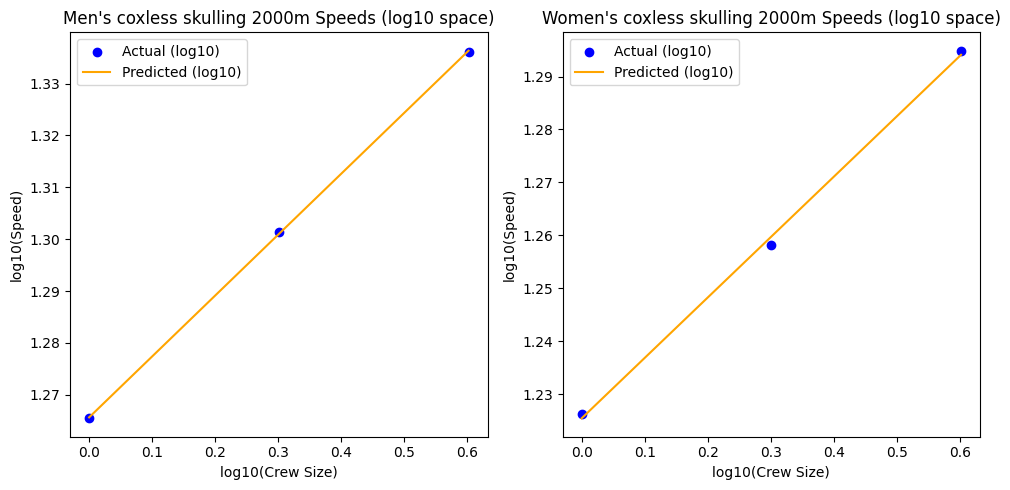

coxless rowing Men's Regression Results:
Men's Slope: 0.12523906259660803, Intercept: 1.2531942897657802
coxless rowing Women's Regression Results:
Women's Slope: 0.12099236678656078, Intercept: 1.2111983945287987


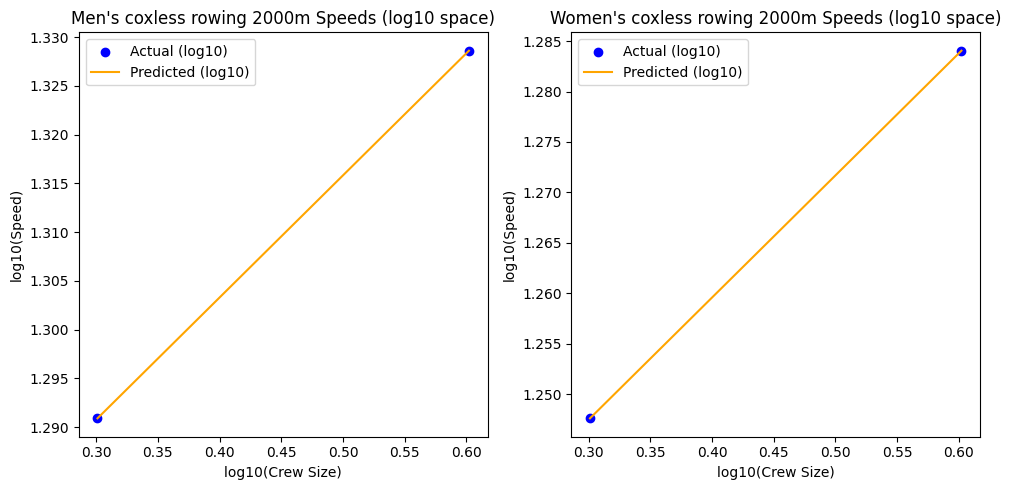

coxed rowing Men's Regression Results:
Men's Slope: 0.15168748580162497, Intercept: 1.2149806500788607
No data available for women in coxed rowing


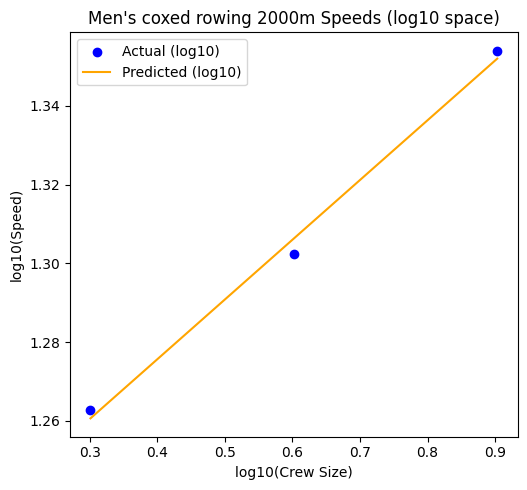

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Updated rowing data
row_data = {
    "coxless skulling": [
        {"gender": "men", "numberOfRowers": 1, "time": "6:30.74"},
        {"gender": "men", "numberOfRowers": 2, "time": "5:59.72"},
        {"gender": "men", "numberOfRowers": 4, "time": "5:32.03"},
        {"gender": "women", "numberOfRowers": 1, "time": "7:07.71"},
        {"gender": "women", "numberOfRowers": 2, "time": "6:37.31"},
        {"gender": "women", "numberOfRowers": 4, "time": "6:05.13"}
    ],
    "coxless rowing": [
        {"gender": "men", "numberOfRowers": 2, "time": "6:08.50"},
        {"gender": "men", "numberOfRowers": 4, "time": "5:37.86"},
        {"gender": "women", "numberOfRowers": 2, "time": "6:47.11"},
        {"gender": "women", "numberOfRowers": 4, "time": "6:14.36"}
    ],
    "coxed rowing": [
        {"gender": "men", "numberOfRowers": 2, "time": "6:33.26"},
        {"gender": "men", "numberOfRowers": 4, "time": "5:58.96"},
        {"gender": "men", "numberOfRowers": 8, "time": "5:18.68"}
    ]
}

# Function to convert time format (mm:ss.xx) to total seconds
def time_to_speed(time_str):
    minutes, seconds = map(float, time_str.split(':'))
    time_seconds = minutes * 60 + seconds
    return (2000 / time_seconds) * 3.6

# Prepare lists for crew size and times for men and women for each boat type
def prepare_data(data):
    men_crew_sizes, men_times, women_crew_sizes, women_times = [], [], [], []

    for entry in data:
        crew_size = entry['numberOfRowers']
        speed = time_to_speed(entry['time'])

        if entry['gender'] == 'men':
            men_crew_sizes.append(crew_size)
            men_times.append(speed)
        elif entry['gender'] == 'women':
            women_crew_sizes.append(crew_size)
            women_times.append(speed)

    return np.array(men_crew_sizes).reshape(-1, 1), np.array(men_times), np.array(women_crew_sizes).reshape(-1, 1), np.array(women_times)

# Extract and convert times to speeds for each boat type
def process_data(boat_type):
    men_crew_sizes, men_times, women_crew_sizes, women_times = prepare_data(row_data[boat_type])
    
    # Convert times to speeds
    men_speeds = np.array(men_times)
    women_speeds = np.array(women_times)

    # Convert to log10 space
    men_crew_sizes_log = np.log10(men_crew_sizes) if len(men_crew_sizes) > 0 else np.array([])
    women_crew_sizes_log = np.log10(women_crew_sizes) if len(women_crew_sizes) > 0 else np.array([])
    men_speeds_log = np.log10(men_speeds) if len(men_speeds) > 0 else np.array([])
    women_speeds_log = np.log10(women_speeds) if len(women_speeds) > 0 else np.array([])

    return men_crew_sizes_log, men_speeds_log, women_crew_sizes_log, women_speeds_log

# Initialize and train regression models and plot results
def plot_results(boat_type):
    men_crew_sizes_log, men_speeds_log, women_crew_sizes_log, women_speeds_log = process_data(boat_type)
    
    # Plotting the results
    plt.figure(figsize=(10, 5))

    # Plot actual and predicted speeds for men
    if len(men_crew_sizes_log) > 0 and len(men_speeds_log) > 0:
        men_regression_speed_log = LinearRegression().fit(men_crew_sizes_log, men_speeds_log)
        men_predicted_speeds_log = men_regression_speed_log.predict(men_crew_sizes_log)
        
        print(f"{boat_type} Men's Regression Results:")
        print(f"Men's Slope: {men_regression_speed_log.coef_[0]}, Intercept: {men_regression_speed_log.intercept_}")
        
        plt.subplot(1, 2, 1)
        plt.scatter(men_crew_sizes_log, men_speeds_log, label='Actual (log10)', color='blue')
        plt.plot(men_crew_sizes_log, men_predicted_speeds_log, label='Predicted (log10)', color='orange')
        plt.title(f"Men's {boat_type} 2000m Speeds (log10 space)")
        plt.xlabel('log10(Crew Size)')
        plt.ylabel('log10(Speed)')
        plt.legend()
    else:
        print(f"No data available for men in {boat_type}")
    
    # Plot actual and predicted speeds for women
    if len(women_crew_sizes_log) > 0 and len(women_speeds_log) > 0:
        women_regression_speed_log = LinearRegression().fit(women_crew_sizes_log, women_speeds_log)
        women_predicted_speeds_log = women_regression_speed_log.predict(women_crew_sizes_log)
        
        print(f"{boat_type} Women's Regression Results:")
        print(f"Women's Slope: {women_regression_speed_log.coef_[0]}, Intercept: {women_regression_speed_log.intercept_}")

        plt.subplot(1, 2, 2)
        plt.scatter(women_crew_sizes_log, women_speeds_log, label='Actual (log10)', color='blue')
        plt.plot(women_crew_sizes_log, women_predicted_speeds_log, label='Predicted (log10)', color='orange')
        plt.title(f"Women's {boat_type} 2000m Speeds (log10 space)")
        plt.xlabel('log10(Crew Size)')
        plt.ylabel('log10(Speed)')
        plt.legend()
    else:
        print(f"No data available for women in {boat_type}")

    plt.tight_layout()
    plt.show()

# Plot results for each boat type
for boat_type in row_data.keys():
    plot_results(boat_type)


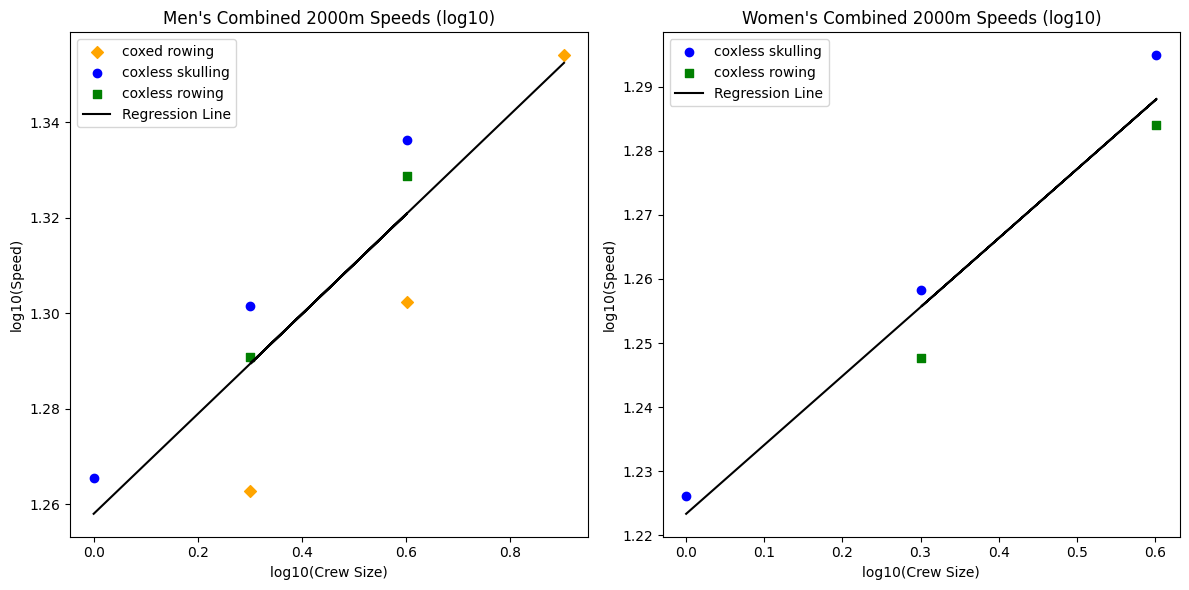

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Updated rowing data
row_data = {
    "coxless skulling": [
        {"gender": "men", "numberOfRowers": 1, "time": "6:30.74"},
        {"gender": "men", "numberOfRowers": 2, "time": "5:59.72"},
        {"gender": "men", "numberOfRowers": 4, "time": "5:32.03"},
        {"gender": "women", "numberOfRowers": 1, "time": "7:07.71"},
        {"gender": "women", "numberOfRowers": 2, "time": "6:37.31"},
        {"gender": "women", "numberOfRowers": 4, "time": "6:05.13"}
    ],
    "coxless rowing": [
        {"gender": "men", "numberOfRowers": 2, "time": "6:08.50"},
        {"gender": "men", "numberOfRowers": 4, "time": "5:37.86"},
        {"gender": "women", "numberOfRowers": 2, "time": "6:47.11"},
        {"gender": "women", "numberOfRowers": 4, "time": "6:14.36"}
    ],
    "coxed rowing": [
        {"gender": "men", "numberOfRowers": 2, "time": "6:33.26"},
        {"gender": "men", "numberOfRowers": 4, "time": "5:58.96"},
        {"gender": "men", "numberOfRowers": 8, "time": "5:18.68"}
    ]
}

# Function to convert time format (mm:ss.xx) to total seconds
def time_to_speed(time_str):
    minutes, seconds = map(float, time_str.split(':'))
    time_seconds = minutes * 60 + seconds
    return (2000 / time_seconds) * 3.6

# Prepare data by combining all boat types
def prepare_combined_data(row_data):
    men_crew_sizes, men_speeds, men_events = [], [], []
    women_crew_sizes, women_speeds, women_events = [], [], []

    for boat_type, entries in row_data.items():
        for entry in entries:
            crew_size = entry['numberOfRowers']
            speed = time_to_speed(entry['time'])
            
            if entry['gender'] == 'men':
                men_crew_sizes.append(crew_size)
                men_speeds.append(speed)
                men_events.append(boat_type)
            elif entry['gender'] == 'women':
                women_crew_sizes.append(crew_size)
                women_speeds.append(speed)
                women_events.append(boat_type)

    return (np.array(men_crew_sizes).reshape(-1, 1), np.array(men_speeds), men_events,
            np.array(women_crew_sizes).reshape(-1, 1), np.array(women_speeds), women_events)

# Plot the combined results for men and women with boat type markers
def plot_combined_results(men_crew_sizes, men_speeds, men_events, women_crew_sizes, women_speeds, women_events):
    markers = {'coxless skulling': 'o', 'coxless rowing': 's', 'coxed rowing': 'D'}
    colors = {'coxless skulling': 'blue', 'coxless rowing': 'green', 'coxed rowing': 'orange'}
    
    # Convert to log10 space
    men_crew_sizes_log = np.log10(men_crew_sizes)
    women_crew_sizes_log = np.log10(women_crew_sizes)
    men_speeds_log = np.log10(men_speeds)
    women_speeds_log = np.log10(women_speeds)
    
    # Create a 1/9th line
    def one_ninth_line(crew_sizes_log):
        return crew_sizes_log * (1/9)
    
    # Men: Fit regression and plot
    men_regression = LinearRegression().fit(men_crew_sizes_log, men_speeds_log)
    men_predicted_speeds_log = men_regression.predict(men_crew_sizes_log)
    
    # Women: Fit regression and plot
    women_regression = LinearRegression().fit(women_crew_sizes_log, women_speeds_log)
    women_predicted_speeds_log = women_regression.predict(women_crew_sizes_log)

    # Plot Men
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    for event in set(men_events):
        event_indices = [i for i, e in enumerate(men_events) if e == event]
        plt.scatter(men_crew_sizes_log[event_indices], men_speeds_log[event_indices],
                    label=f'{event}', marker=markers[event], color=colors[event])

    # Plot men regression line and 1/9 line
    plt.plot(men_crew_sizes_log, men_predicted_speeds_log, label='Regression Line', color='black')
    # plt.plot(men_crew_sizes_log, one_ninth_line(men_crew_sizes_log), label='1/9 Line', linestyle='--', color='red')

    plt.title("Men's Combined 2000m Speeds (log10)")
    plt.xlabel('log10(Crew Size)')
    plt.ylabel('log10(Speed)')
    plt.legend()

    # Plot Women
    plt.subplot(1, 2, 2)
    for event in set(women_events):
        event_indices = [i for i, e in enumerate(women_events) if e == event]
        plt.scatter(women_crew_sizes_log[event_indices], women_speeds_log[event_indices],
                    label=f'{event}', marker=markers[event], color=colors[event])

    # Plot women regression line and 1/9 line
    plt.plot(women_crew_sizes_log, women_predicted_speeds_log, label='Regression Line', color='black')
    # plt.plot(women_crew_sizes_log, one_ninth_line(women_crew_sizes_log), label='1/9 Line', linestyle='--', color='red')

    plt.title("Women's Combined 2000m Speeds (log10)")
    plt.xlabel('log10(Crew Size)')
    plt.ylabel('log10(Speed)')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Combine all data
men_crew_sizes, men_speeds, men_events, women_crew_sizes, women_speeds, women_events = prepare_combined_data(row_data)

# Plot the combined results
plot_combined_results(men_crew_sizes, men_speeds, men_events, women_crew_sizes, women_speeds, women_events)


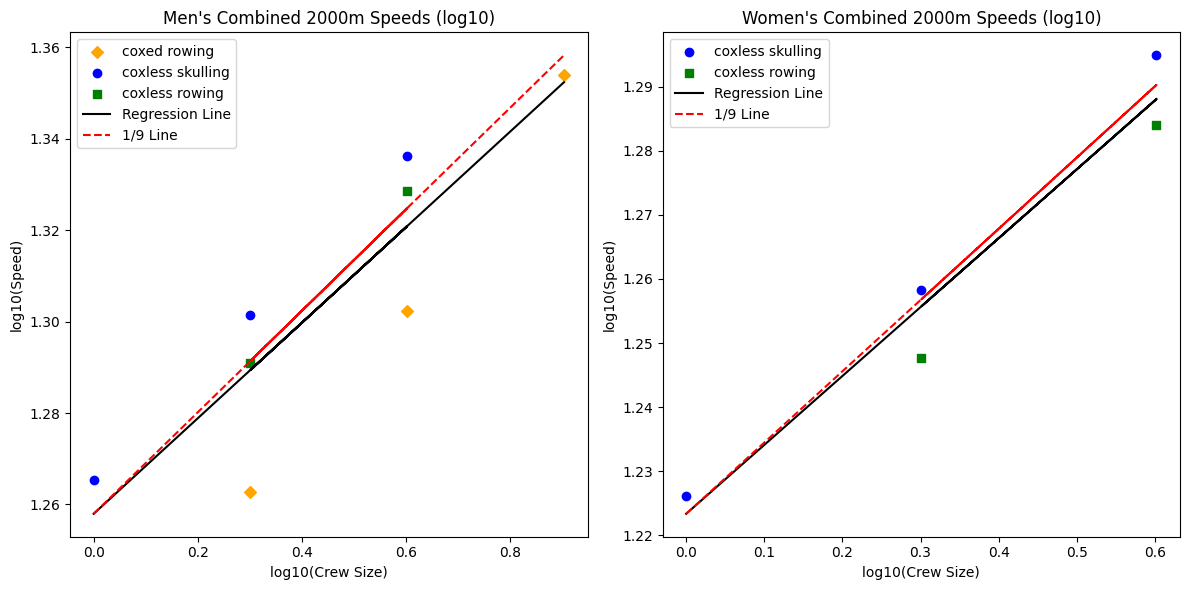

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Updated rowing data
row_data = {
    "coxless skulling": [
        {"gender": "men", "numberOfRowers": 1, "time": "6:30.74"},
        {"gender": "men", "numberOfRowers": 2, "time": "5:59.72"},
        {"gender": "men", "numberOfRowers": 4, "time": "5:32.03"},
        {"gender": "women", "numberOfRowers": 1, "time": "7:07.71"},
        {"gender": "women", "numberOfRowers": 2, "time": "6:37.31"},
        {"gender": "women", "numberOfRowers": 4, "time": "6:05.13"}
    ],
    "coxless rowing": [
        {"gender": "men", "numberOfRowers": 2, "time": "6:08.50"},
        {"gender": "men", "numberOfRowers": 4, "time": "5:37.86"},
        {"gender": "women", "numberOfRowers": 2, "time": "6:47.11"},
        {"gender": "women", "numberOfRowers": 4, "time": "6:14.36"}
    ],
    "coxed rowing": [
        {"gender": "men", "numberOfRowers": 2, "time": "6:33.26"},
        {"gender": "men", "numberOfRowers": 4, "time": "5:58.96"},
        {"gender": "men", "numberOfRowers": 8, "time": "5:18.68"}
    ]
}

# Function to convert time format (mm:ss.xx) to total seconds
def time_to_speed(time_str):
    minutes, seconds = map(float, time_str.split(':'))
    time_seconds = minutes * 60 + seconds
    return (2000 / time_seconds) * 3.6

# Prepare data by combining all boat types
def prepare_combined_data(row_data):
    men_crew_sizes, men_speeds, men_events = [], [], []
    women_crew_sizes, women_speeds, women_events = [], [], []

    for boat_type, entries in row_data.items():
        for entry in entries:
            crew_size = entry['numberOfRowers']
            speed = time_to_speed(entry['time'])
            
            if entry['gender'] == 'men':
                men_crew_sizes.append(crew_size)
                men_speeds.append(speed)
                men_events.append(boat_type)
            elif entry['gender'] == 'women':
                women_crew_sizes.append(crew_size)
                women_speeds.append(speed)
                women_events.append(boat_type)

    return (np.array(men_crew_sizes).reshape(-1, 1), np.array(men_speeds), men_events,
            np.array(women_crew_sizes).reshape(-1, 1), np.array(women_speeds), women_events)

# Plot the combined results for men and women with boat type markers
def plot_combined_results(men_crew_sizes, men_speeds, men_events, women_crew_sizes, women_speeds, women_events):
    markers = {'coxless skulling': 'o', 'coxless rowing': 's', 'coxed rowing': 'D'}
    colors = {'coxless skulling': 'blue', 'coxless rowing': 'green', 'coxed rowing': 'orange'}
    
    # Convert to log10 space
    men_crew_sizes_log = np.log10(men_crew_sizes)
    women_crew_sizes_log = np.log10(women_crew_sizes)
    men_speeds_log = np.log10(men_speeds)
    women_speeds_log = np.log10(women_speeds)
    
    # Create centered 1/9th line using the intercept from the regression line
    def one_ninth_line(crew_sizes_log, intercept):
        return intercept + crew_sizes_log * (.1111)
    
    # Men: Fit regression and plot
    men_regression = LinearRegression().fit(men_crew_sizes_log, men_speeds_log)
    men_predicted_speeds_log = men_regression.predict(men_crew_sizes_log)
    men_intercept = men_regression.intercept_  # Intercept to use for centering the 1/9 line
    
    # Women: Fit regression and plot
    women_regression = LinearRegression().fit(women_crew_sizes_log, women_speeds_log)
    women_predicted_speeds_log = women_regression.predict(women_crew_sizes_log)
    women_intercept = women_regression.intercept_  # Intercept to use for centering the 1/9 line

    # Plot Men
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    for event in set(men_events):
        event_indices = [i for i, e in enumerate(men_events) if e == event]
        plt.scatter(men_crew_sizes_log[event_indices], men_speeds_log[event_indices],
                    label=f'{event}', marker=markers[event], color=colors[event])

    # Plot men regression line and centered 1/9 line
    plt.plot(men_crew_sizes_log, men_predicted_speeds_log, label='Regression Line', color='black')
    plt.plot(men_crew_sizes_log, one_ninth_line(men_crew_sizes_log, men_intercept), label='1/9 Line', linestyle='--', color='red')

    plt.title("Men's Combined 2000m Speeds (log10)")
    plt.xlabel('log10(Crew Size)')
    plt.ylabel('log10(Speed)')
    plt.legend()

    # Plot Women
    plt.subplot(1, 2, 2)
    for event in set(women_events):
        event_indices = [i for i, e in enumerate(women_events) if e == event]
        plt.scatter(women_crew_sizes_log[event_indices], women_speeds_log[event_indices],
                    label=f'{event}', marker=markers[event], color=colors[event])

    # Plot women regression line and centered 1/9 line
    plt.plot(women_crew_sizes_log, women_predicted_speeds_log, label='Regression Line', color='black')
    plt.plot(women_crew_sizes_log, one_ninth_line(women_crew_sizes_log, women_intercept), label='1/9 Line', linestyle='--', color='red')

    plt.title("Women's Combined 2000m Speeds (log10)")
    plt.xlabel('log10(Crew Size)')
    plt.ylabel('log10(Speed)')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Combine all data
men_crew_sizes, men_speeds, men_events, women_crew_sizes, women_speeds, women_events = prepare_combined_data(row_data)

# Plot the combined results
plot_combined_results(men_crew_sizes, men_speeds, men_events, women_crew_sizes, women_speeds, women_events)


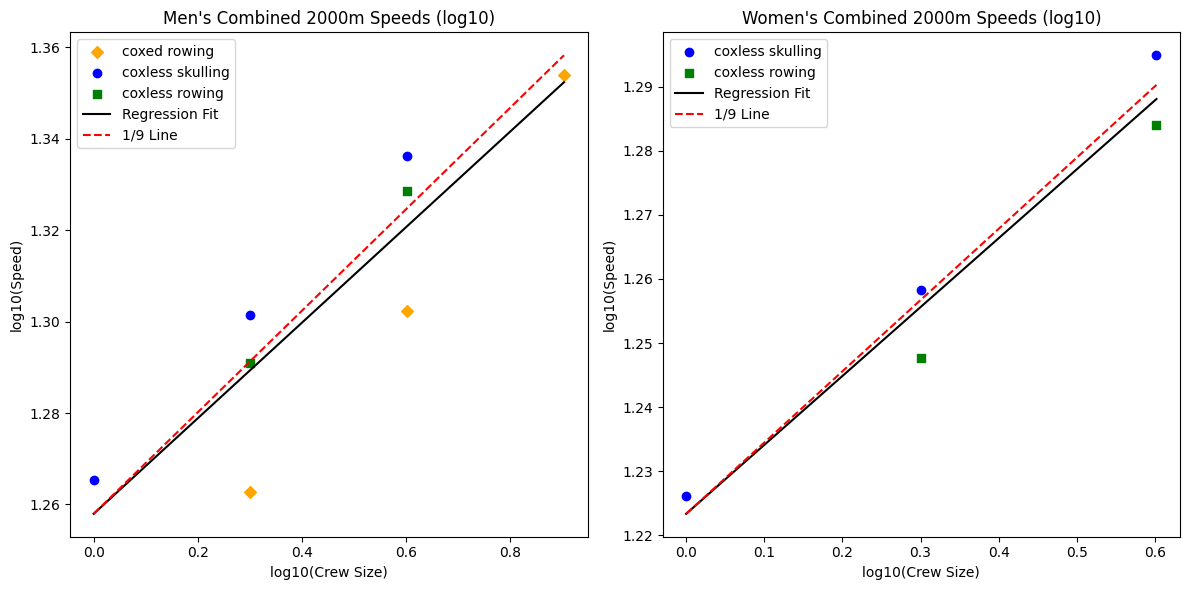

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Updated rowing data
row_data = {
    "coxless skulling": [
        {"gender": "men", "numberOfRowers": 1, "time": "6:30.74"},
        {"gender": "men", "numberOfRowers": 2, "time": "5:59.72"},
        {"gender": "men", "numberOfRowers": 4, "time": "5:32.03"},
        {"gender": "women", "numberOfRowers": 1, "time": "7:07.71"},
        {"gender": "women", "numberOfRowers": 2, "time": "6:37.31"},
        {"gender": "women", "numberOfRowers": 4, "time": "6:05.13"}
    ],
    "coxless rowing": [
        {"gender": "men", "numberOfRowers": 2, "time": "6:08.50"},
        {"gender": "men", "numberOfRowers": 4, "time": "5:37.86"},
        {"gender": "women", "numberOfRowers": 2, "time": "6:47.11"},
        {"gender": "women", "numberOfRowers": 4, "time": "6:14.36"}
    ],
    "coxed rowing": [
        {"gender": "men", "numberOfRowers": 2, "time": "6:33.26"},
        {"gender": "men", "numberOfRowers": 4, "time": "5:58.96"},
        {"gender": "men", "numberOfRowers": 8, "time": "5:18.68"}
    ]
}

# Function to convert time format (mm:ss.xx) to total seconds
def time_to_speed(time_str):
    minutes, seconds = map(float, time_str.split(':'))
    time_seconds = minutes * 60 + seconds
    return (2000 / time_seconds) * 3.6

# Prepare data by combining all boat types
def prepare_combined_data(row_data):
    men_crew_sizes, men_speeds, men_events = [], [], []
    women_crew_sizes, women_speeds, women_events = [], [], []

    for boat_type, entries in row_data.items():
        for entry in entries:
            crew_size = entry['numberOfRowers']
            speed = time_to_speed(entry['time'])
            
            if entry['gender'] == 'men':
                men_crew_sizes.append(crew_size)
                men_speeds.append(speed)
                men_events.append(boat_type)
            elif entry['gender'] == 'women':
                women_crew_sizes.append(crew_size)
                women_speeds.append(speed)
                women_events.append(boat_type)

    return (np.array(men_crew_sizes).reshape(-1, 1), np.array(men_speeds), men_events,
            np.array(women_crew_sizes).reshape(-1, 1), np.array(women_speeds), women_events)

# Plot the combined results for men and women with boat type markers
def plot_combined_results(men_crew_sizes, men_speeds, men_events, women_crew_sizes, women_speeds, women_events):
    markers = {'coxless skulling': 'o', 'coxless rowing': 's', 'coxed rowing': 'D'}
    colors = {'coxless skulling': 'blue', 'coxless rowing': 'green', 'coxed rowing': 'orange'}
    
    # Convert to log10 space
    men_crew_sizes_log = np.log10(men_crew_sizes)
    women_crew_sizes_log = np.log10(women_crew_sizes)
    men_speeds_log = np.log10(men_speeds)
    women_speeds_log = np.log10(women_speeds)
    
    # Create centered 1/9th line using the intercept from the regression line
    def one_ninth_line(crew_sizes_log, intercept):
        return intercept + crew_sizes_log * (.1111)
    
    # Men: Fit regression and plot
    men_regression = LinearRegression().fit(men_crew_sizes_log, men_speeds_log)
    men_intercept = men_regression.intercept_  # Intercept to use for centering the 1/9 line
    
    # Women: Fit regression and plot
    women_regression = LinearRegression().fit(women_crew_sizes_log, women_speeds_log)
    women_intercept = women_regression.intercept_  # Intercept to use for centering the 1/9 line

    # Plot Men
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    for event in set(men_events):
        event_indices = [i for i, e in enumerate(men_events) if e == event]
        plt.scatter(men_crew_sizes_log[event_indices], men_speeds_log[event_indices],
                    label=f'{event}', marker=markers[event], color=colors[event])

    # Plot men regression line (fit) and centered 1/9 line
    crew_sizes_fit = np.linspace(min(men_crew_sizes_log), max(men_crew_sizes_log), 100)
    fitted_line = men_regression.intercept_ + crew_sizes_fit * men_regression.coef_[0]  # The fitted regression line
    plt.plot(crew_sizes_fit, fitted_line, label='Regression Fit', color='black')  # Plot fit line
    plt.plot(crew_sizes_fit, one_ninth_line(crew_sizes_fit, men_intercept), label='1/9 Line', linestyle='--', color='red')

    plt.title("Men's Combined 2000m Speeds (log10)")
    plt.xlabel('log10(Crew Size)')
    plt.ylabel('log10(Speed)')
    plt.legend()

    # Plot Women
    plt.subplot(1, 2, 2)
    for event in set(women_events):
        event_indices = [i for i, e in enumerate(women_events) if e == event]
        plt.scatter(women_crew_sizes_log[event_indices], women_speeds_log[event_indices],
                    label=f'{event}', marker=markers[event], color=colors[event])

    # Plot women regression line (fit) and centered 1/9 line
    crew_sizes_fit_women = np.linspace(min(women_crew_sizes_log), max(women_crew_sizes_log), 100)
    fitted_line_women = women_regression.intercept_ + crew_sizes_fit_women * women_regression.coef_[0]  # The fitted regression line
    plt.plot(crew_sizes_fit_women, fitted_line_women, label='Regression Fit', color='black')  # Plot fit line
    plt.plot(crew_sizes_fit_women, one_ninth_line(crew_sizes_fit_women, women_intercept), label='1/9 Line', linestyle='--', color='red')

    plt.title("Women's Combined 2000m Speeds (log10)")
    plt.xlabel('log10(Crew Size)')
    plt.ylabel('log10(Speed)')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Combine all data
men_crew_sizes, men_speeds, men_events, women_crew_sizes, women_speeds, women_events = prepare_combined_data(row_data)

# Plot the combined results
plot_combined_results(men_crew_sizes, men_speeds, men_events, women_crew_sizes, women_speeds, women_events)


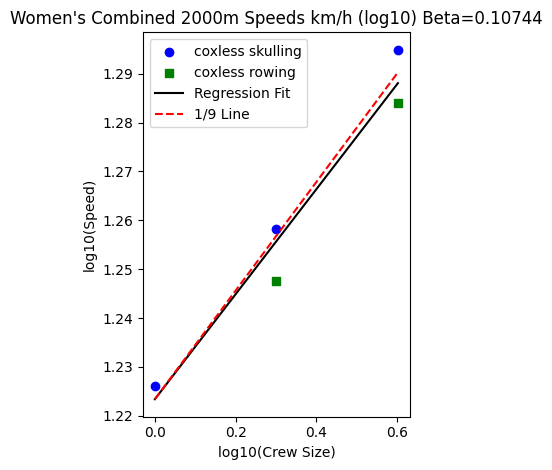

<Figure size 640x480 with 0 Axes>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Updated rowing data
row_data = {
    "coxless skulling": [
        {"gender": "men", "numberOfRowers": 1, "time": "6:30.74"},
        {"gender": "men", "numberOfRowers": 2, "time": "5:59.72"},
        {"gender": "men", "numberOfRowers": 4, "time": "5:32.03"},
        {"gender": "women", "numberOfRowers": 1, "time": "7:07.71"},
        {"gender": "women", "numberOfRowers": 2, "time": "6:37.31"},
        {"gender": "women", "numberOfRowers": 4, "time": "6:05.13"}
    ],
    "coxless rowing": [
        {"gender": "men", "numberOfRowers": 2, "time": "6:08.50"},
        {"gender": "men", "numberOfRowers": 4, "time": "5:37.86"},
        {"gender": "women", "numberOfRowers": 2, "time": "6:47.11"},
        {"gender": "women", "numberOfRowers": 4, "time": "6:14.36"}
    ],
    "coxed rowing": [
        {"gender": "men", "numberOfRowers": 2, "time": "6:33.26"},
        {"gender": "men", "numberOfRowers": 4, "time": "5:58.96"},
        {"gender": "men", "numberOfRowers": 8, "time": "5:18.68"}
    ]
}

# Function to convert time format (mm:ss.xx) to total seconds
def time_to_speed(time_str):
    minutes, seconds = map(float, time_str.split(':'))
    time_seconds = minutes * 60 + seconds
    return round((2000 / time_seconds) * 3.6, 5)

# Prepare data by combining all boat types
def prepare_combined_data(row_data):
    men_crew_sizes, men_speeds, men_events = [], [], []
    women_crew_sizes, women_speeds, women_events = [], [], []

    for boat_type, entries in row_data.items():
        for entry in entries:
            crew_size = entry['numberOfRowers']
            speed = time_to_speed(entry['time'])
            
            if entry['gender'] == 'men':
                men_crew_sizes.append(crew_size)
                men_speeds.append(speed)
                men_events.append(boat_type)
            elif entry['gender'] == 'women':
                women_crew_sizes.append(crew_size)
                women_speeds.append(speed)
                women_events.append(boat_type)

    return (np.array(men_crew_sizes).reshape(-1, 1), np.array(men_speeds), men_events,
            np.array(women_crew_sizes).reshape(-1, 1), np.array(women_speeds), women_events)

# Plot the combined results for men and women with boat type markers
def plot_combined_results(men_crew_sizes, men_speeds, men_events, women_crew_sizes, women_speeds, women_events):
    markers = {'coxless skulling': 'o', 'coxless rowing': 's', 'coxed rowing': 'D'}
    colors = {'coxless skulling': 'blue', 'coxless rowing': 'green', 'coxed rowing': 'orange'}
    
    # Convert to log10 space
    men_crew_sizes_log = np.log10(men_crew_sizes)
    women_crew_sizes_log = np.log10(women_crew_sizes)
    men_speeds_log = np.log10(men_speeds)
    women_speeds_log = np.log10(women_speeds)
    
    # Create centered 1/9th line using the intercept from the regression line
    def one_ninth_line(crew_sizes_log, intercept):
        return intercept + crew_sizes_log * (1/9)
    
    # Men: Fit regression and plot
    men_regression = LinearRegression().fit(men_crew_sizes_log, men_speeds_log)
    men_intercept = men_regression.intercept_  # Intercept to use for centering the 1/9 line
    men_residuals = men_speeds_log - men_regression.predict(men_crew_sizes_log)  # Residuals for men
        # Mean Squared Error of residuals
    MMSE = np.sum(men_residuals**2) / (len(men_crew_sizes_log) - 2)
    
    # Variance of X (log scale)
    SSX = np.sum((men_crew_sizes_log - np.mean(men_crew_sizes_log))**2)
    
    # Standard Error of Slope
    SES = np.sqrt(MMSE / SSX)
    # print(SES)
    # Women: Fit regression and plot
    women_regression = LinearRegression().fit(women_crew_sizes_log, women_speeds_log)
    women_intercept = women_regression.intercept_  # Intercept to use for centering the 1/9 line
    women_residuals = women_speeds_log - women_regression.predict(women_crew_sizes_log)  # Residuals for women

    # Plot Men
    # plt.figure(figsize=(12, 6))
    # plt.subplot(1, 2, 1)
    # for event in set(men_events):
    #     event_indices = [i for i, e in enumerate(men_events) if e == event]
    #     plt.scatter(men_crew_sizes_log[event_indices], men_speeds_log[event_indices],
    #                 label=f'{event}', marker=markers[event], color=colors[event])

    # # Plot men regression line (fit) and centered 1/9 line
    # crew_sizes_fit = np.linspace(min(men_crew_sizes_log), max(men_crew_sizes_log), 100)
    # fitted_line = men_regression.intercept_ + crew_sizes_fit * men_regression.coef_[0]  # The fitted regression line
    # plt.plot(crew_sizes_fit, fitted_line, label='Regression Fit', color='black')  # Plot fit line
    # plt.plot(crew_sizes_fit, one_ninth_line(crew_sizes_fit, men_intercept), label='1/9 Line', linestyle='--', color='red')

    # plt.title(f"Men's Combined 2000m Speeds km/h (log10) Beta={round(men_regression.coef_[0], 5)}")
    # plt.xlabel('log10(Crew Size)')
    # plt.ylabel('log10(Speed)')
    # plt.legend()

    # Plot Women
    plt.subplot(1, 2, 2)
    for event in set(women_events):
        event_indices = [i for i, e in enumerate(women_events) if e == event]
        plt.scatter(women_crew_sizes_log[event_indices], women_speeds_log[event_indices],
                    label=f'{event}', marker=markers[event], color=colors[event])

    # Plot women regression line (fit) and centered 1/9 line
    crew_sizes_fit_women = np.linspace(min(women_crew_sizes_log), max(women_crew_sizes_log), 100)
    fitted_line_women = women_regression.intercept_ + crew_sizes_fit_women * women_regression.coef_[0]  # The fitted regression line
    plt.plot(crew_sizes_fit_women, fitted_line_women, label='Regression Fit', color='black')  # Plot fit line
    plt.plot(crew_sizes_fit_women, one_ninth_line(crew_sizes_fit_women, women_intercept), label='1/9 Line', linestyle='--', color='red')

    plt.title(f"Women's Combined 2000m Speeds km/h (log10) Beta={round(women_regression.coef_[0], 5)}")
    plt.xlabel('log10(Crew Size)')
    plt.ylabel('log10(Speed)')
    plt.legend()

    plt.tight_layout()
    plt.show()

    # # Plot residuals for men and women
    # plt.figure(figsize=(10, 5))
    # plt.subplot(1, 2, 1)
    # plt.bar(range(len(men_residuals)), men_residuals, color='blue')
    # plt.title("Men's Residuals")
    # plt.xlabel('Data Point')
    # plt.ylabel('Residual (log10 Speed)')

    # plt.subplot(1, 2, 2)
    # plt.bar(range(len(women_residuals)), women_residuals, color='orange')
    # plt.title("Women's Residuals")
    # plt.xlabel('Data Point')
    # plt.ylabel('Residual (log10 Speed)')

    plt.tight_layout()
    plt.show()

# Combine all data
men_crew_sizes, men_speeds, men_events, women_crew_sizes, women_speeds, women_events = prepare_combined_data(row_data)

# Plot the combined results
plot_combined_results(men_crew_sizes, men_speeds, men_events, women_crew_sizes, women_speeds, women_events)


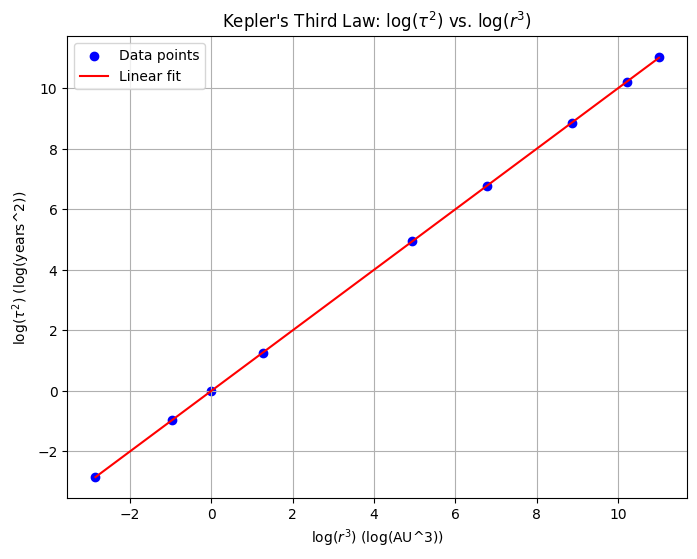

Slope: 0.9993020269892597
Intercept: 0.0021572766663044973
R^2 value: 0.9999960280176853


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Data for planets (including Pluto)
# Orbital period (τ in Earth years) and semi-major axis (r in AU)
data = {
    "Planet": ["Mercury", "Venus", "Earth", "Mars", "Jupiter", "Saturn", "Uranus", "Neptune", "Pluto"],
    "Tau (years)": [0.241, 0.615, 1.000, 1.88, 11.9, 29.4, 83.7, 164, 248],
    "r (AU)": [0.386, 0.724, 1.000, 1.52, 5.20, 9.58, 19.2, 30.1, 39.3]
}

# Convert to DataFrame
df = pd.DataFrame(data)

# Calculate tau^2 and r^3
df['Tau^2'] = df['Tau (years)'] ** 2
df['r^3'] = df['r (AU)'] ** 3

# Perform linear regression in log-log space
X_log = np.log(df['r^3']).values.reshape(-1, 1)
y_log = np.log(df['Tau^2']).values.reshape(-1, 1)


# Linear regression model
model = LinearRegression()
model.fit(X_log, y_log)

# Regression predictions
y_pred_log = model.predict(X_log)

# Calculate R^2 for goodness of fit
r_squared = model.score(X_log, y_log)

# Plot results
plt.figure(figsize=(8,6))
plt.scatter(np.log(df['r^3']), np.log(df['Tau^2']), label='Data points', color='blue')
plt.plot(np.log(df['r^3']), y_pred_log, label='Linear fit', color='red')
plt.xlabel('log($r^3$) (log(AU^3))')
plt.ylabel('log($\\tau^2$) (log(years^2))')
plt.title("Kepler's Third Law: log($\\tau^2$) vs. log($r^3$)")
plt.legend()
plt.grid(True)
plt.show()

# Output results
slope = model.coef_[0][0]
intercept = model.intercept_[0]

print(f"Slope: {slope}")
print(f"Intercept: {intercept}")
print(f"R^2 value: {r_squared}")


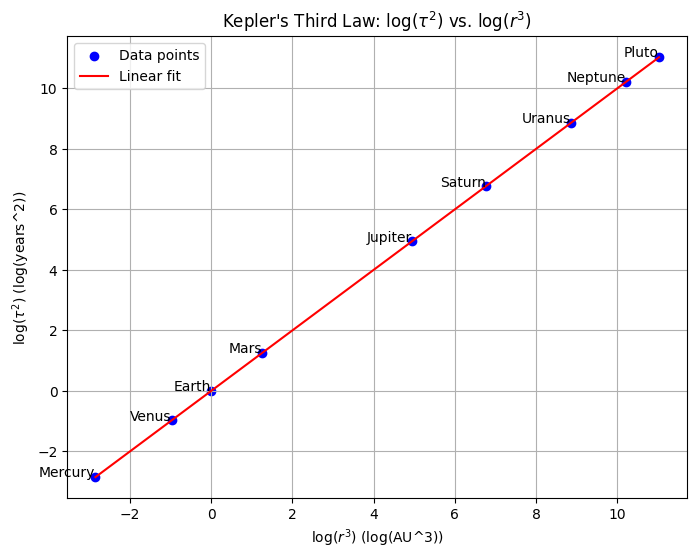

Slope: 0.9999953024399182
Intercept: 0.00040917947265128873
R^2 value: 0.9999960280176853


In [ ]:
# Re-import necessary libraries and redefine the data for the new plot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Data for planets (including Pluto)
data = {
    "Planet": ["Mercury", "Venus", "Earth", "Mars", "Jupiter", "Saturn", "Uranus", "Neptune", "Pluto"],
    "Tau (years)": [0.241, 0.615, 1.000, 1.881, 11.86, 29.46, 84.01, 164.8, 248.6],
    "r (AU)": [0.387, 0.723, 1.000, 1.524, 5.203, 9.537, 19.19, 30.07, 39.48]
}

# Convert to DataFrame
df = pd.DataFrame(data)

# Calculate tau^2 and r^3
df['Tau^2'] = df['Tau (years)'] ** 2
df['r^3'] = df['r (AU)'] ** 3

# Perform linear regression in log-log space
X_log = np.log(df['r^3']).values.reshape(-1, 1)
y_log = np.log(df['Tau^2']).values.reshape(-1, 1)

# Linear regression model
model = LinearRegression()
model.fit(X_log, y_log)

# Regression predictions
y_pred_log = model.predict(X_log)

# Planet names for labeling
planets = ["Mercury", "Venus", "Earth", "Mars", "Jupiter", "Saturn", "Uranus", "Neptune", "Pluto"]

# Re-plot the graph
plt.figure(figsize=(8,6))
plt.scatter(np.log(df['r^3']), np.log(df['Tau^2']), label='Data points', color='blue')

# Add planet labels
for i, planet in enumerate(planets):
    plt.text(np.log(df['r^3'])[i], np.log(df['Tau^2'])[i], planet, fontsize=10, ha='right')

plt.plot(np.log(df['r^3']), y_pred_log, label='Linear fit', color='red')
plt.xlabel('log($r^3$) (log(AU^3))')
plt.ylabel('log($\\tau^2$) (log(years^2))')
plt.title("Kepler's Third Law: log($\\tau^2$) vs. log($r^3$)")
plt.legend()
plt.grid(True)
plt.show()

slope = model.coef_[0][0]
intercept = model.intercept_[0]

print(f"Slope: {slope}")
print(f"Intercept: {intercept}")
print(f"R^2 value: {r_squared}")


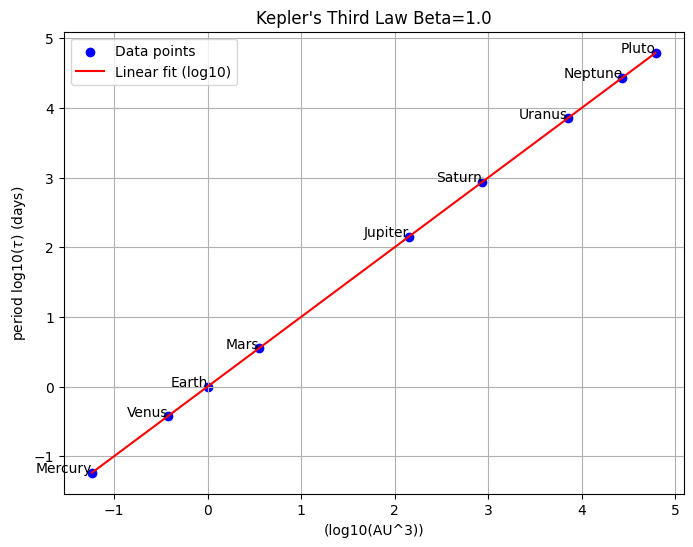

(0.9999953024399179, 0.00017770438708097913, 0.9999998723289313)

In [ ]:
# Re-import necessary libraries and redefine the data for the log10 plot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Data for planets (including Pluto)
data = {
    "Planet": ["Mercury", "Venus", "Earth", "Mars", "Jupiter", "Saturn", "Uranus", "Neptune", "Pluto"],
    "Tau (years)": [0.241, 0.615, 1.000, 1.881, 11.86, 29.46, 84.01, 164.8, 248.6],
    "r (AU)": [0.387, 0.723, 1.000, 1.524, 5.203, 9.537, 19.19, 30.07, 39.48]
}

# Convert to DataFrame
df = pd.DataFrame(data)

# Calculate tau^2 and r^3
df['Tau^2'] = df['Tau (years)'] ** 2
df['r^3'] = df['r (AU)'] ** 3

# Perform linear regression using log base 10 (log10) instead of natural log (ln)
X_log10 = np.log10(df['r^3']).values.reshape(-1, 1)
y_log10 = np.log10(df['Tau^2']).values.reshape(-1, 1)

# Fit the linear regression model using log10
model_log10 = LinearRegression()
model_log10.fit(X_log10, y_log10)

# Regression predictions for log10
y_pred_log10 = model_log10.predict(X_log10)

# Calculate R^2 for the log10 fit
r_squared_log10 = model_log10.score(X_log10, y_log10)

# Re-plot the graph using log10 and include planet names
planets = ["Mercury", "Venus", "Earth", "Mars", "Jupiter", "Saturn", "Uranus", "Neptune", "Pluto"]
plt.figure(figsize=(8,6))
plt.scatter(np.log10(df['r^3']), np.log10(df['Tau^2']), label='Data points', color='blue')

# Add planet labels
for i, planet in enumerate(planets):
    plt.text(np.log10(df['r^3'])[i], np.log10(df['Tau^2'])[i], planet, fontsize=10, ha='right')

# Plot the linear fit using log10
plt.plot(np.log10(df['r^3']), y_pred_log10, label='Linear fit (log10)', color='red')
plt.xlabel('(log10(AU^3))')
plt.ylabel('period log10($\\tau$) (days)')
plt.title(f"Kepler's Third Law Beta={round(model_log10.coef_[0][0], 5)}")
plt.legend()
plt.grid(True)
plt.show()

# Output slope, intercept, and R^2 for the log10 fit
slope_log10 = model_log10.coef_[0][0]
intercept_log10 = model_log10.intercept_[0]
slope_log10, intercept_log10, r_squared_log10
